In [1]:
import torchcurves.functional as tcf
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional
import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import trange

# Simulate auctions

In [2]:
@dataclass
class Buyer:
    mean_budget: float
    budget: float
    preferences: np.typing.NDArray

    @classmethod
    def draw_player(cls, rng=None, mean_budget=1000, dim=10):
        if rng is None:
            rng = np.random

        return cls(
            mean_budget=mean_budget,
            budget=rng.exponential(scale=mean_budget),
            preferences=rng.normal(size=dim)
        )

    def reset_budget(self, rng=None):
        if rng is None:
            rng = np.random

        self.budget = rng.exponential(scale=self.mean_budget)

    def bid(self, auction_features: np.typing.NDArray, rng=None):
        if rng is None:
            rng = np.random

        # linear preferences
        mean_bid = np.reciprocal(np.linalg.norm(self.preferences - auction_features))
        return min(self.budget, rng.exponential(scale=mean_bid))

    def charge(self, amount: float):
        self.budget -= amount


class Seller:
    def __init__(self, dim: int, rng: Optional[np.random.Generator] = None, floor_price_mean: float = 2):
        if rng is None:
            rng = np.random

        self.rng = rng
        self.features = rng.standard_normal(size=dim)
        self.std = 0.5 / np.sqrt(dim)
        self.floor_price = rng.exponential(scale=floor_price_mean)

    def draw_auction_features(self) -> np.typing.NDArray:
        return self.features + self.std * rng.standard_normal(len(self.features))

In [3]:
n_players = 50     # us and n_players - 1 competitors
n_sellers = 10

feature_dim = 3
n_auctions = 10000
n_days = 5
mean_budget = 2 * n_auctions * np.sqrt(feature_dim) / n_players
rng = np.random.default_rng(42)

In [4]:
players = [Buyer.draw_player(rng, dim=feature_dim, mean_budget=mean_budget) for _ in range(n_players)]
player_prefs = np.vstack([player.preferences for player in players])
sellers = [Seller(feature_dim, rng) for _ in range(n_sellers)]
seller_weights = rng.uniform(size=n_sellers)
seller_weights /= np.sum(seller_weights)

auction_features = []
budget_fractions = []
seller_idxs = []
our_bids = []
our_wins = []
wins_per_seller = np.zeros(n_sellers)
auctions_per_seller = np.zeros(n_sellers)
for day in trange(n_days, leave=True):
    for i in trange(n_auctions, leave=False):
        current_auction_features = rng.normal(size=feature_dim)

        seller_idx = rng.choice(n_sellers, p=seller_weights)
        seller_idxs.append(seller_idx)

        seller = sellers[seller_idx]
        current_auction_features = seller.draw_auction_features()
        floor_price = seller.floor_price

        bids = np.asarray([player.bid(current_auction_features, rng) for player in players])
        bids = np.where(bids < floor_price, 0., bids)
        if np.all(bids == 0):
            continue

        winner_idx = np.argmax(bids)
        winner_bid = bids[winner_idx]

        auction_features.append(current_auction_features)
        budget_fractions.append(players[0].budget / players[0].mean_budget)
        our_bids.append(bids[0])

        win_indicator = 1. if winner_idx == 0 and bids[0] > 0 else 0.
        our_wins.append(win_indicator)
        wins_per_seller[seller_idx] += win_indicator
        auctions_per_seller[seller_idx] += 1

        players[winner_idx].charge(winner_bid)

    for player in players:
        player.reset_budget(rng)

auction_features = np.vstack(auction_features)
budget_fractions = np.asarray(budget_fractions)
seller_idxs = np.asarray(seller_idxs)
our_bids = np.asarray(our_bids)
our_wins = np.asarray(our_wins)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

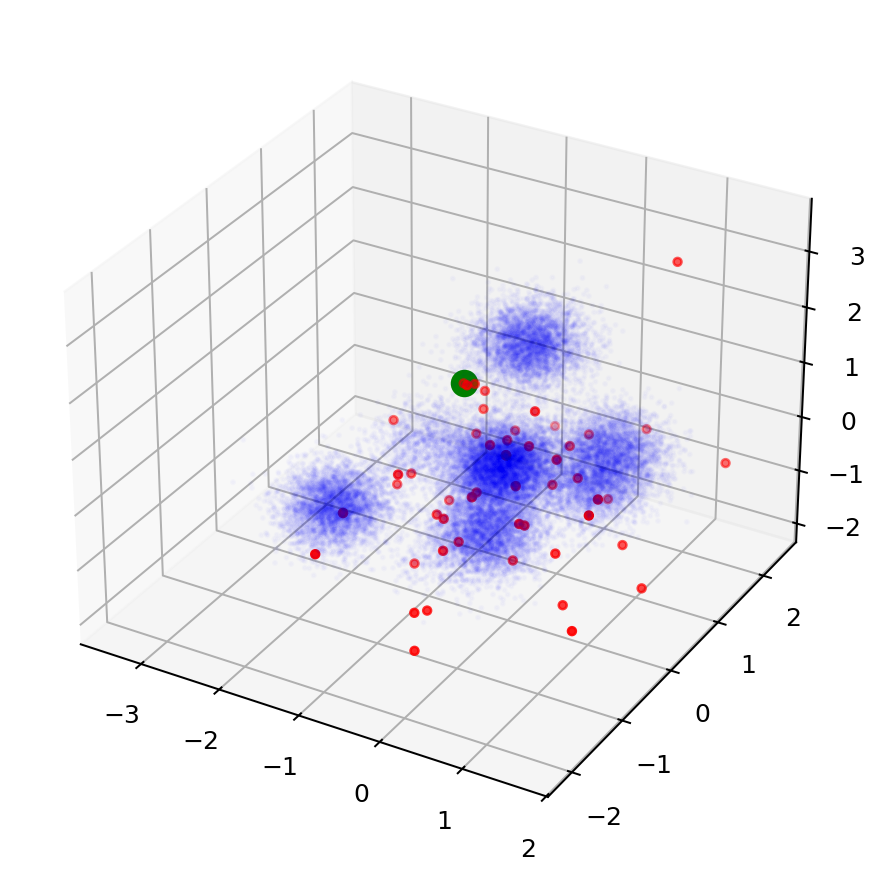

In [5]:
fig = plt.figure(dpi=180, figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(*np.hsplit(auction_features, 3), c='blue', s=2, alpha=0.02)
ax.scatter(*np.hsplit(player_prefs, 3), c='red', s=10)
ax.scatter(*players[0].preferences, c='green', s=100)
plt.show()

<BarContainer object of 10 artists>

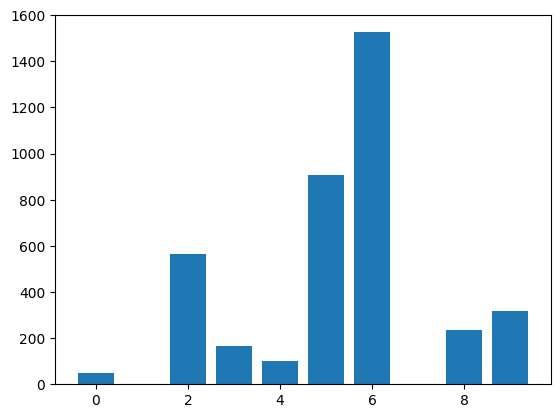

In [6]:
plt.bar(np.arange(n_sellers), wins_per_seller / seller_weights)

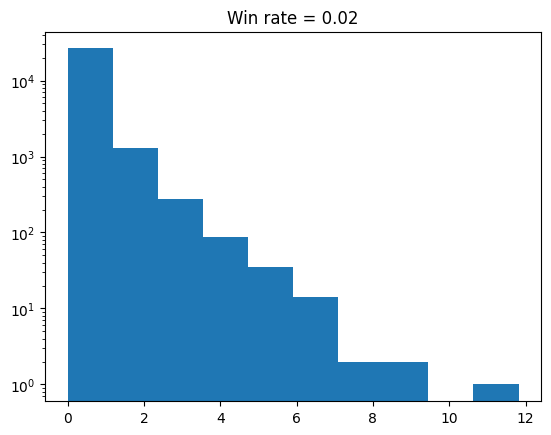

In [7]:
plt.hist(our_bids, log=True)
plt.title(f'Win rate = {our_wins.mean():.2f}')
plt.show()

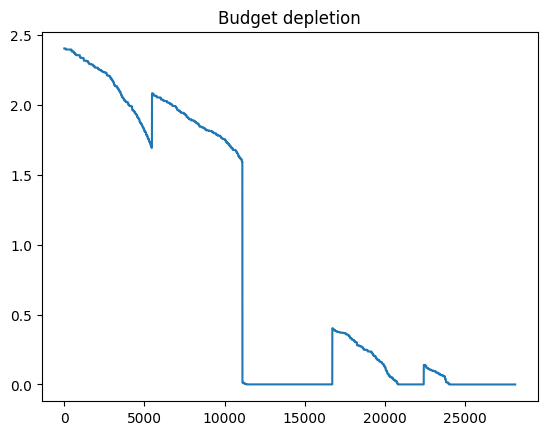

In [8]:
plt.plot(budget_fractions)
plt.title('Budget depletion')
plt.show()

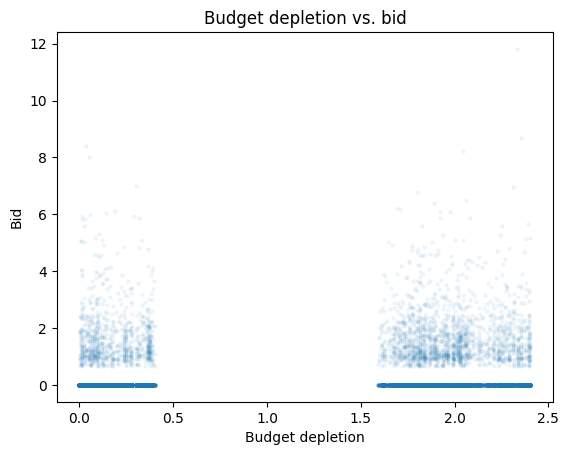

In [9]:
plt.scatter(budget_fractions, our_bids, s=5, alpha=0.05)
plt.plot()
plt.title('Budget depletion vs. bid')
plt.xlabel('Budget depletion')
plt.ylabel('Bid')
plt.show()

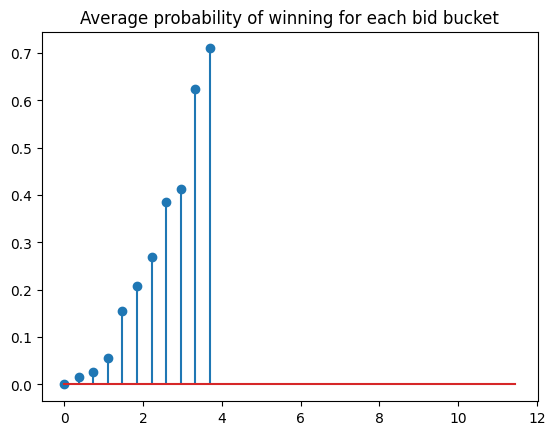

In [10]:
def bucket_means(b, p, n):
    # Uniform bucket edges on [min(b), max(b)]
    edges = np.linspace(b.min(), b.max(), n + 1)

    # Map each b to a bucket index in [0, n-1]
    idx = np.searchsorted(edges, b, side='right') - 1
    idx = np.clip(idx, 0, n - 1)

    # Weighted sum and counts per bucket
    sums = np.bincount(idx, weights=p, minlength=n)
    counts = np.bincount(idx, minlength=n)

    # Means, with zeros for empty buckets
    means = np.divide(sums, counts,
                      out=np.full(n, np.nan, dtype=float),
                      where=counts > 30)

    return edges[:-1], means

plt.stem(*bucket_means(our_bids, our_wins, 32))
plt.title('Average probability of winning for each bid bucket')
plt.show()

# Prepare train / validation data

In [11]:
def to_torch(mask, *arrays):
    tensors = (torch.as_tensor(t[mask], dtype=torch.get_default_dtype()) for t in arrays)
    return TensorDataset(*tensors)

In [12]:
# features include budget fractions
X = np.hstack((auction_features, budget_fractions.reshape(-1, 1)))

In [13]:
train_frac = 0.8
train_mask = rng.random(size=X.shape[0]) < train_frac
train_ds = to_torch(train_mask, X, our_bids, our_wins)
val_ds = to_torch(~train_mask, X, our_bids, our_wins)
max_bid = np.max(our_bids).item()

# Define the model

In [14]:
def make_mlp(input_dim: int, output_dim: int, num_hidden_layers: int, hidden_dim: int):
        return nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            *(
                layer for _ in range(num_hidden_layers) for layer in [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
            ),
            nn.Linear(hidden_dim, output_dim),
        )

In [15]:
class BidModel(nn.Module):
    def __init__(self, input_dim: int, num_coefficients: int, num_hidden_layers: int):
        super().__init__()
        self.degree = 3
        hidden_dim = 4 * max(input_dim, num_coefficients)
        self.mlp = make_mlp(input_dim, num_coefficients, num_hidden_layers, hidden_dim)
        self.register_buffer("knots", tcf.uniform_augmented_knots(num_coefficients, degree=self.degree, k_min=0, k_max=1))

    def forward(self, auction_features: torch.Tensor, bid: torch.Tensor) -> torch.Tensor:
        # map auction features to increasing spline coefficients via MLP + increasing transform
        coefficients = self.mlp(auction_features)
        increasing_coefficients = self._make_increasing(coefficients)

        # map bids to [0, 1] using the arctan (or any other) normalization
        mapped_bid = tcf.arctan(bid)

        # compute a B-Spline function that by-design increases with the bid!
        return tcf.bspline_curves(
            mapped_bid.unsqueeze(-1),
            increasing_coefficients.unsqueeze(-1),
            self.knots,
            self.degree
        ).squeeze([-1, -2])

    @staticmethod
    def _make_increasing(x):
        initial = x[..., :1]
        increments = nn.functional.softplus(x[..., 1:])
        concatenated = torch.concat((initial, increments), dim=-1)
        return torch.cumsum(concatenated, dim=-1)

In [16]:
# model params
num_coefficients = 50
num_hidden_layers = 10

# training params
num_epochs = 10
batch_size = 128
lr = 5e-4
weight_decay = 1e-8

# create model, loss, optimizer, and dataloaders
model = BidModel(X.shape[1], num_coefficients, num_hidden_layers)
loss = nn.BCEWithLogitsLoss()
opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)

# training loop
for epoch in range(1, 1 + num_epochs):
    epoch_loss = torch.tensor(0.)
    for X_batch, bid_batch, win_batch in train_dl:
        opt.zero_grad()
        y_pred = model(X_batch, bid_batch)
        loss_val = loss(y_pred, win_batch)
        loss_val.backward()
        opt.step()

        with torch.no_grad():
            epoch_loss += loss_val * len(X_batch)
    epoch_loss /= len(train_ds)

    with torch.no_grad():
        for X_batch, bid_batch, win_batch in val_dl:
            y_pred = model(X_batch, bid_batch)
            valid_loss = loss(y_pred, win_batch)

    print(f'Epoch = {epoch}, Loss = {epoch_loss:.4f}, Valid Loss = {valid_loss:.4f}')

/home/alex/git/torchcurves/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:824: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch = 1, Loss = 0.1597, Valid Loss = 0.0304
Epoch = 2, Loss = 0.0325, Valid Loss = 0.0340
Epoch = 3, Loss = 0.0332, Valid Loss = 0.0300
Epoch = 4, Loss = 0.0325, Valid Loss = 0.0318
Epoch = 5, Loss = 0.0325, Valid Loss = 0.0310
Epoch = 6, Loss = 0.0332, Valid Loss = 0.0305
Epoch = 7, Loss = 0.0326, Valid Loss = 0.0304
Epoch = 8, Loss = 0.0329, Valid Loss = 0.0348
Epoch = 9, Loss = 0.0331, Valid Loss = 0.0302
Epoch = 10, Loss = 0.0321, Valid Loss = 0.0309


# Take several random auction features and see P(win | auction, bid) as a function of the bid

tensor([[-8.0477, -1.9079, -2.3151, -2.2783, -1.7706, -2.8358, -1.1594, -2.4962,
         -1.3649, -1.7444, -2.1918, -0.6739, -1.9434,  0.1199, -2.1234, -1.9999,
         -1.7575, -1.9776, -1.9878, -2.1156, -1.6457, -1.9594, -2.2009, -2.5358,
         -0.7439, -3.2807, -2.8535, -1.2067, -1.4030, -1.8415, -1.5856, -1.2469,
         -0.2948, -2.3886, -3.2548, -3.0468, -2.6491,  0.0766, -2.8065, -2.8124,
          1.3821, -1.9154, -2.5780,  0.3367,  8.2523,  9.6327,  2.4527,  0.8574,
          0.8157, -0.2563]])
tensor([[-8.0477, -1.9079, -2.3151, -2.2783, -1.7706, -2.8358, -1.1594, -2.4962,
         -1.3649, -1.7444, -2.1918, -0.6739, -1.9434,  0.1199, -2.1234, -1.9999,
         -1.7575, -1.9776, -1.9878, -2.1156, -1.6457, -1.9594, -2.2009, -2.5358,
         -0.7439, -3.2807, -2.8535, -1.2067, -1.4030, -1.8415, -1.5856, -1.2469,
         -0.2948, -2.3886, -3.2548, -3.0468, -2.6491,  0.0766, -2.8065, -2.8124,
          1.3821, -1.9154, -2.5780,  0.3367,  8.2523,  9.6327,  2.4527,  0.8574,

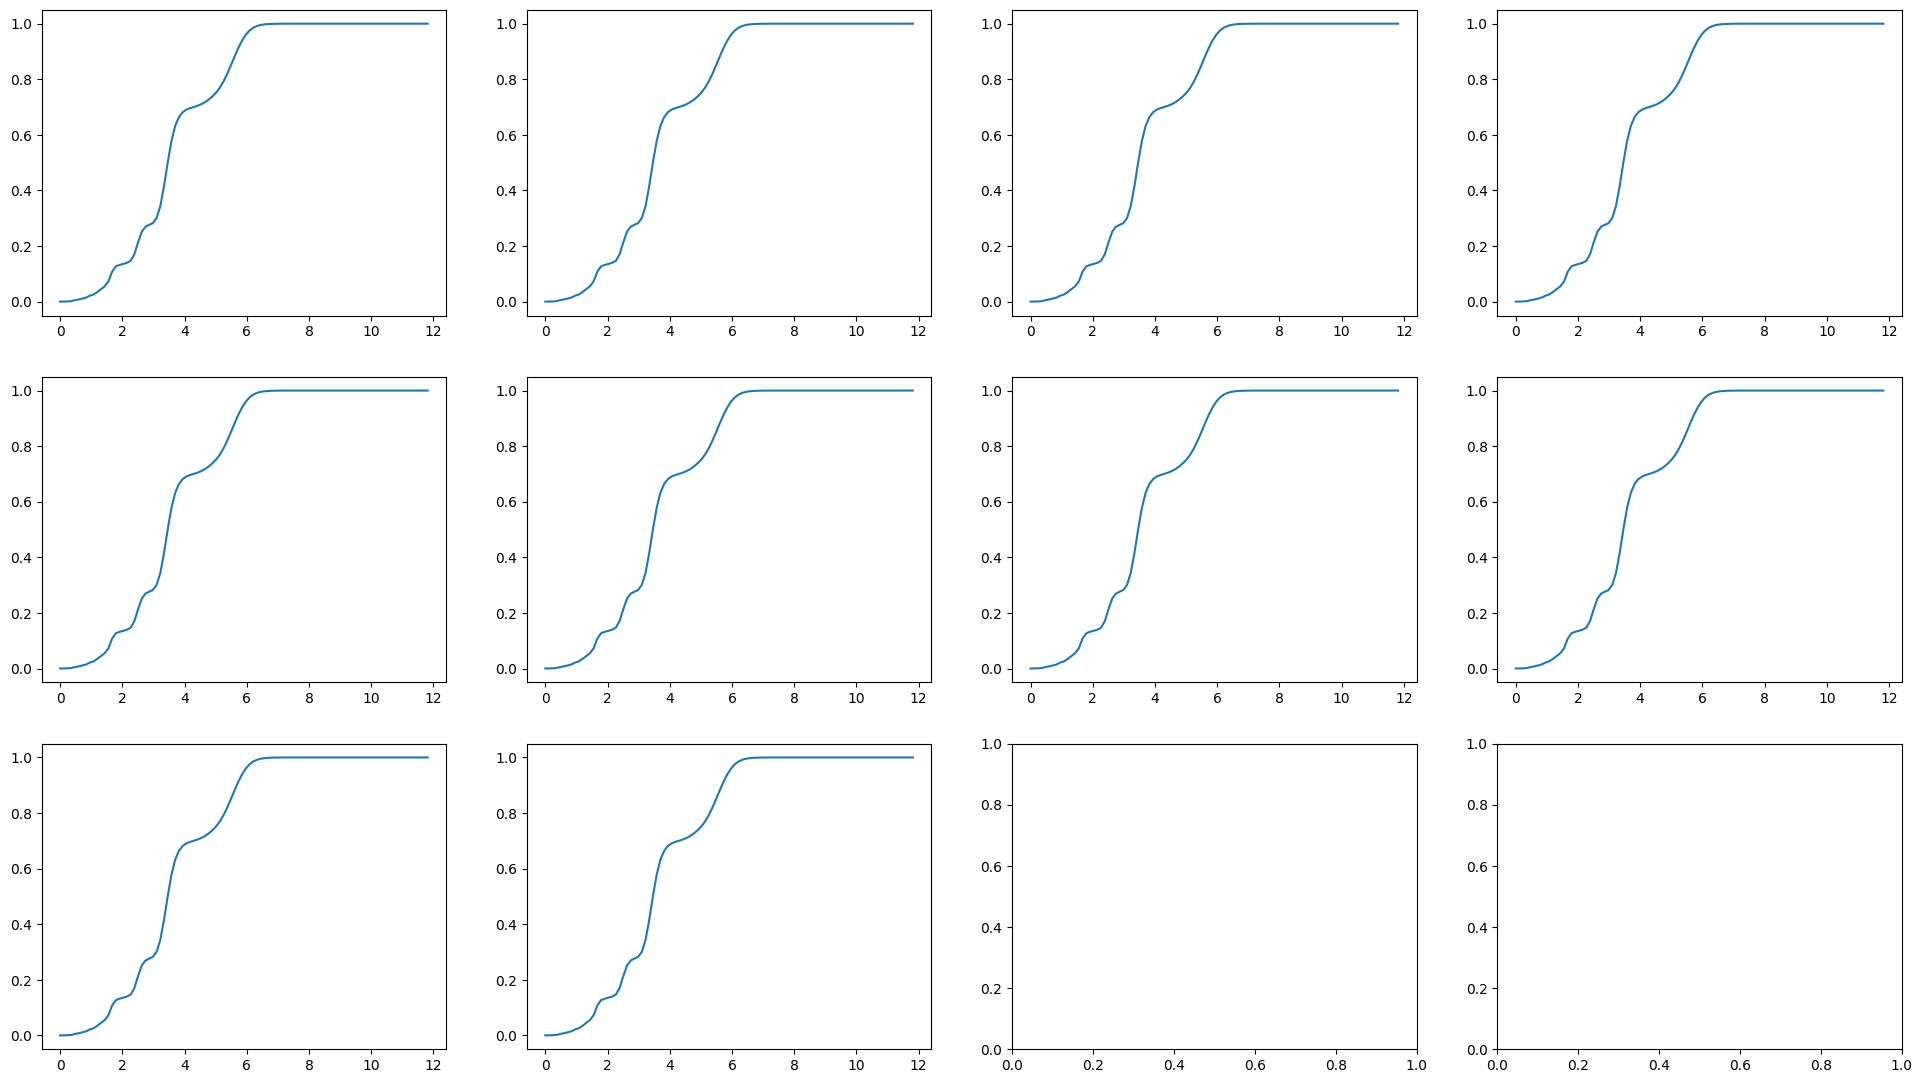

In [17]:
num_plot_cols = 4
num_plot_rows = int(np.ceil(n_sellers / num_plot_cols).item())
plot_resolution = 100

fig, axs = plt.subplots(num_plot_rows, num_plot_cols, figsize=(6 * num_plot_cols, 4.5 * num_plot_rows))
plot_bids = torch.linspace(0, max_bid, plot_resolution)
for ax, seller in zip(axs.ravel(), sellers):
    with torch.no_grad():
        auction_features = torch.as_tensor(seller.features.reshape(1, -1), dtype=torch.get_default_dtype())
        auction_features = torch.concat((auction_features, torch.ones((1, 1))), dim=-1)
        pred_logits = model(auction_features.expand(plot_resolution, -1), plot_bids)
        pred_probs = torch.sigmoid(pred_logits)

        mlp_output = model.mlp(auction_features)
        print(mlp_output)

    ax.plot(plot_bids, pred_probs)